# 03 XAI-Erklaerungen

Ziel: globale und lokale Modell-Erklaerungen fuer ausgewaehlte Modelle erstellen. Startpunkt sind Permutation Importance und SHAP. LIME kann spaeter ergaenzt werden.

In [1]:
from pathlib import Path
import os
import ssl
import urllib.request
import warnings

import certifi

# Helps Python installations that do not find the system certificate store.
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
NOTEBOOK_DIR = Path.cwd()
REPORT_GRAPHICS_DIR = NOTEBOOK_DIR.parent / "XAI_Projektarbeit 19.54.42" / "Graphics"
REPORT_GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)


/Users/lukadeda/xai/projektarbeit/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_url = "https://archive.ics.uci.edu/static/public/602/data.csv"
with urllib.request.urlopen(data_url, context=ssl.create_default_context(cafile=certifi.where())) as response:
    df_all = pd.read_csv(response)

X_all = df_all.drop(columns=["Class"])
y = df_all["Class"]

expected_classes = {"SEKER", "BARBUNYA", "BOMBAY", "CALI", "DERMASON", "HOROZ", "SIRA"}
assert X_all.shape == (13611, 16), f"Unexpected feature shape: {X_all.shape}"
assert y.shape[0] == 13611, f"Unexpected target length: {y.shape[0]}"
assert set(y.unique()) == expected_classes, f"Unexpected classes: {sorted(y.unique())}"
assert X_all.isna().sum().sum() == 0, "Unexpected missing values in features"
assert y.isna().sum() == 0, "Unexpected missing values in target"

selected_features = [
    "Area",
    "AspectRatio",
    "Eccentricity",
    "Compactness",
    "Roundness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor4",
]
X = X_all[selected_features]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

model = RandomForestClassifier(
    n_estimators=25,
    class_weight=None,
    max_depth=None,
    max_features="log2",
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)
f1_score(y_test, model.predict(X_test), average="macro")

0.9311654788132865

## Permutation Importance

Permutation Importance misst, wie stark die Modellleistung sinkt, wenn ein Feature zufaellig vertauscht wird. Dadurch ist die Methode modellunabhaengig und gut als globale Erklaerung geeignet.

In [3]:
perm = permutation_importance(
    model, X_test, y_test, scoring="f1_macro", n_repeats=20, random_state=RANDOM_STATE
)

perm_df = (
    pd.DataFrame({
        "feature": selected_features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)
perm_df

,feature,importance_mean,importance_std
5,ShapeFactor1,0.244875,0.006040
4,Roundness,0.117835,0.004542
0,Area,0.078763,0.005001
3,Compactness,0.055477,0.004395
7,ShapeFactor4,0.036654,0.002657
6,ShapeFactor2,0.033452,0.002969
1,AspectRatio,0.003624,0.001979
2,Eccentricity,0.002255,0.001530


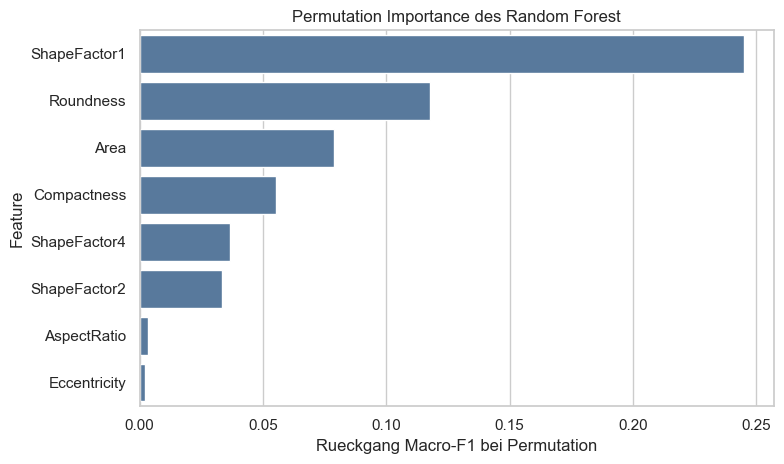

In [4]:
plt.figure(figsize=(8, 4.8))
sns.barplot(data=perm_df, x="importance_mean", y="feature", color="#4c78a8")
plt.title("Permutation Importance des Random Forest")
plt.xlabel("Rueckgang Macro-F1 bei Permutation")
plt.ylabel("Feature")
plt.tight_layout()
for output_dir in [NOTEBOOK_DIR, REPORT_GRAPHICS_DIR]:
    plt.savefig(output_dir / "Permutation_Importance_RandomForest.pdf", bbox_inches="tight")
plt.show()

## SHAP

SHAP wird fuer eine globale Merkmalsrangfolge und eine lokale Beispielerklaerung verwendet. Fuer die Laufzeit wird eine reproduzierbare Stichprobe aus den Testdaten genutzt.

In [5]:
X_sample = X_test.sample(n=500, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_sample)

if isinstance(shap_values_raw, list):
    shap_values = np.stack(shap_values_raw, axis=-1)
else:
    shap_values = np.asarray(shap_values_raw)

if shap_values.shape[1] == len(model.classes_):
    shap_values = np.moveaxis(shap_values, 1, -1)

global_shap = np.abs(shap_values).mean(axis=(0, 2))
shap_df = (
    pd.DataFrame({"feature": selected_features, "mean_abs_shap": global_shap})
    .sort_values("mean_abs_shap", ascending=False)
)
shap_df

,feature,mean_abs_shap
5,ShapeFactor1,0.070141
0,Area,0.061019
6,ShapeFactor2,0.046013
3,Compactness,0.042446
4,Roundness,0.028420
1,AspectRatio,0.025208
2,Eccentricity,0.016355
7,ShapeFactor4,0.013575


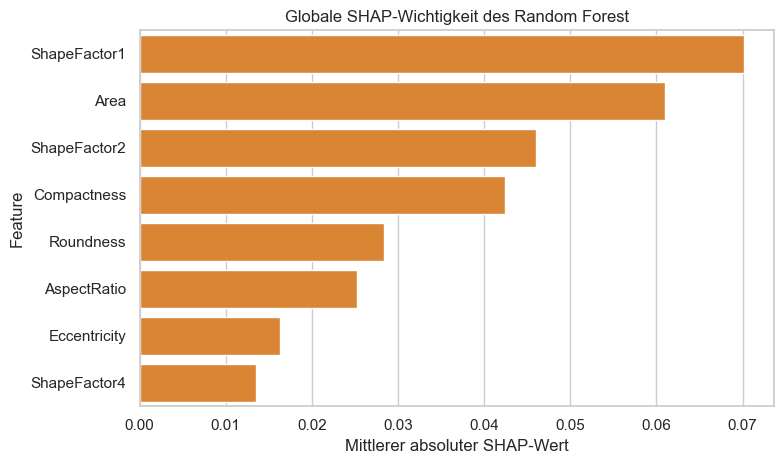

In [6]:
plt.figure(figsize=(8, 4.8))
sns.barplot(data=shap_df, x="mean_abs_shap", y="feature", color="#f58518")
plt.title("Globale SHAP-Wichtigkeit des Random Forest")
plt.xlabel("Mittlerer absoluter SHAP-Wert")
plt.ylabel("Feature")
plt.tight_layout()
for output_dir in [NOTEBOOK_DIR, REPORT_GRAPHICS_DIR]:
    plt.savefig(output_dir / "SHAP_Global_RandomForest.pdf", bbox_inches="tight")
plt.show()

## Lokale SHAP-Erklaerung

Als lokale Erklaerung wird eine korrekt klassifizierte Testinstanz verwendet. Die Abbildung zeigt fuer die vorhergesagte Klasse, welche Merkmale die Modellentscheidung am staerksten nach oben oder unten verschieben.

In [7]:
y_pred = model.predict(X_test)
correct_positions = np.flatnonzero(y_pred == y_test.to_numpy())
example_position = int(correct_positions[0])
example = X_test.iloc[[example_position]]
predicted_class = y_pred[example_position]
class_index = list(model.classes_).index(predicted_class)

example_shap_raw = explainer.shap_values(example)
if isinstance(example_shap_raw, list):
    example_shap = np.stack(example_shap_raw, axis=-1)
else:
    example_shap = np.asarray(example_shap_raw)
if example_shap.shape[1] == len(model.classes_):
    example_shap = np.moveaxis(example_shap, 1, -1)

local_df = (
    pd.DataFrame({
        "feature": selected_features,
        "feature_value": example.iloc[0].to_numpy(),
        "shap_value": example_shap[0, :, class_index],
    })
    .assign(abs_shap=lambda data: data["shap_value"].abs())
    .sort_values("abs_shap", ascending=False)
)
predicted_class, y_test.iloc[example_position], local_df

('DERMASON',
 'DERMASON',
         feature  feature_value  shap_value  abs_shap
 0          Area   36002.000000    0.211063  0.211063
 6  ShapeFactor2       0.002099    0.138672  0.138672
 5  ShapeFactor1       0.007163    0.128484  0.128484
 4     Roundness       0.920954    0.066269  0.066269
 3   Compactness       0.830205    0.036102  0.036102
 7  ShapeFactor4       0.997078    0.016210  0.016210
 2  Eccentricity       0.722605    0.013071  0.013071
 1   AspectRatio       1.446631    0.003388  0.003388)

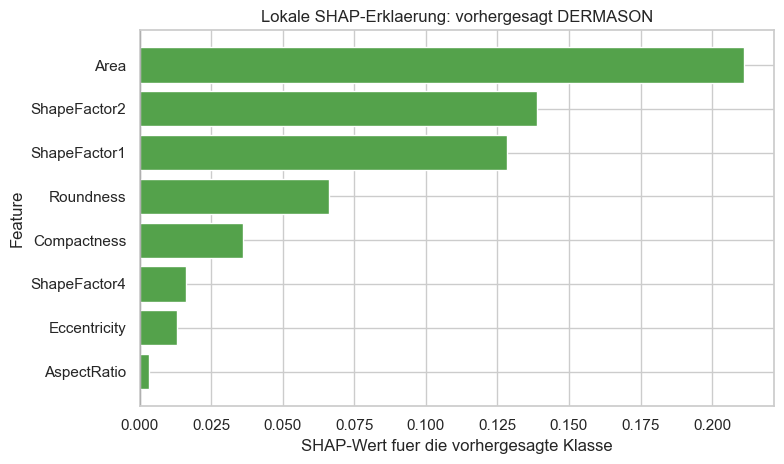

In [8]:
plot_df = local_df.sort_values("shap_value")
colors = np.where(plot_df["shap_value"] >= 0, "#54a24b", "#e45756")
plt.figure(figsize=(8, 4.8))
plt.barh(plot_df["feature"], plot_df["shap_value"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Lokale SHAP-Erklaerung: vorhergesagt {predicted_class}")
plt.xlabel("SHAP-Wert fuer die vorhergesagte Klasse")
plt.ylabel("Feature")
plt.tight_layout()
for output_dir in [NOTEBOOK_DIR, REPORT_GRAPHICS_DIR]:
    plt.savefig(output_dir / "SHAP_Local_RandomForest.pdf", bbox_inches="tight")
plt.show()

## LIME

LIME wird als zweite lokale Erklaerungsmethode fuer dieselbe Testinstanz verwendet. Dadurch lassen sich SHAP und LIME auf Fallebene miteinander vergleichen.

In [9]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=selected_features,
    class_names=list(model.classes_),
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

lime_exp = lime_explainer.explain_instance(
    data_row=example.iloc[0].to_numpy(),
    predict_fn=model.predict_proba,
    labels=[class_index],
    num_features=len(selected_features),
)

lime_df = pd.DataFrame(
    lime_exp.as_list(label=class_index), columns=["condition", "lime_weight"]
).assign(abs_weight=lambda data: data["lime_weight"].abs())
lime_df

/Users/lukadeda/xai/projektarbeit/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,condition,lime_weight,abs_weight
0,Area <= 36324.00,0.289801,0.289801
1,0.00 < ShapeFactor2 <= 0.00,0.091813,0.091813
2,Roundness > 0.92,0.030849,0.030849
3,0.01 < ShapeFactor1 <= 0.01,0.029055,0.029055
4,0.80 < Compactness <= 0.83,0.028890,0.028890
5,1.00 < ShapeFactor4 <= 1.00,0.026390,0.026390
6,1.43 < AspectRatio <= 1.55,0.004141,0.004141
7,0.72 < Eccentricity <= 0.76,0.002273,0.002273


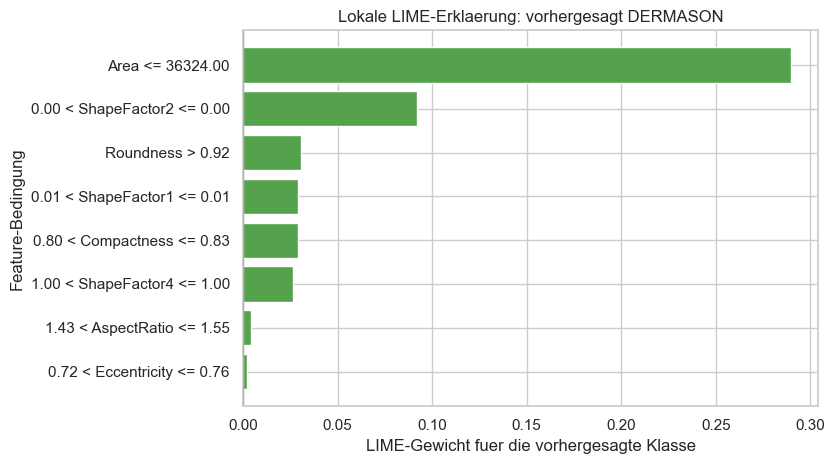

In [10]:
plot_df = lime_df.sort_values("lime_weight")
colors = np.where(plot_df["lime_weight"] >= 0, "#54a24b", "#e45756")
plt.figure(figsize=(8.5, 4.8))
plt.barh(plot_df["condition"], plot_df["lime_weight"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Lokale LIME-Erklaerung: vorhergesagt {predicted_class}")
plt.xlabel("LIME-Gewicht fuer die vorhergesagte Klasse")
plt.ylabel("Feature-Bedingung")
plt.tight_layout()
for output_dir in [NOTEBOOK_DIR, REPORT_GRAPHICS_DIR]:
    plt.savefig(output_dir / "LIME_Local_RandomForest.pdf", bbox_inches="tight")
plt.show()

## Lokale Erklaerung einer Fehlklassifikation

Als zweiter lokaler Fall wird eine Fehlklassifikation aus den bekannten Problemklassen gesucht. Bevorzugt werden Verwechslungen zwischen DERMASON und SIRA oder zwischen BARBUNYA und CALI. Dadurch werden die lokalen XAI-Erklaerungen nicht nur an einem einfachen richtigen Fall, sondern auch an einem typischen Fehlerfall geprueft.

In [11]:
preferred_pairs = [
    ("DERMASON", "SIRA"),
    ("SIRA", "DERMASON"),
    ("BARBUNYA", "CALI"),
    ("CALI", "BARBUNYA"),
]
y_test_array = y_test.to_numpy()
misclassified_positions = np.flatnonzero(y_pred != y_test_array)
if len(misclassified_positions) == 0:
    raise ValueError("Das Modell hat im Testset keine Fehlklassifikation erzeugt.")

misclassified_position = None
for actual_class, predicted_class_candidate in preferred_pairs:
    pair_positions = np.flatnonzero(
        (y_test_array == actual_class) & (y_pred == predicted_class_candidate)
    )
    if len(pair_positions) > 0:
        misclassified_position = int(pair_positions[0])
        break

if misclassified_position is None:
    misclassified_position = int(misclassified_positions[0])

misclassified_example = X_test.iloc[[misclassified_position]]
misclassified_actual_class = y_test.iloc[misclassified_position]
misclassified_predicted_class = y_pred[misclassified_position]
misclassified_class_index = list(model.classes_).index(misclassified_predicted_class)

misclassified_shap_raw = explainer.shap_values(misclassified_example)
if isinstance(misclassified_shap_raw, list):
    misclassified_shap = np.stack(misclassified_shap_raw, axis=-1)
else:
    misclassified_shap = np.asarray(misclassified_shap_raw)
if misclassified_shap.shape[1] == len(model.classes_):
    misclassified_shap = np.moveaxis(misclassified_shap, 1, -1)

misclassified_local_df = (
    pd.DataFrame({
        "feature": selected_features,
        "feature_value": misclassified_example.iloc[0].to_numpy(),
        "shap_value": misclassified_shap[0, :, misclassified_class_index],
    })
    .assign(abs_shap=lambda data: data["shap_value"].abs())
    .sort_values("abs_shap", ascending=False)
)
misclassified_actual_class, misclassified_predicted_class, misclassified_local_df

('DERMASON',
 'SIRA',
         feature  feature_value  shap_value  abs_shap
 5  ShapeFactor1       0.007043    0.150274  0.150274
 4     Roundness       0.880009    0.102265  0.102265
 0          Area   41826.000000    0.098095  0.098095
 3   Compactness       0.783366    0.089768  0.089768
 6  ShapeFactor2       0.001636    0.055409  0.055409
 7  ShapeFactor4       0.997048   -0.037109  0.037109
 2  Eccentricity       0.788153    0.035886  0.035886
 1   AspectRatio       1.624749    0.035610  0.035610)

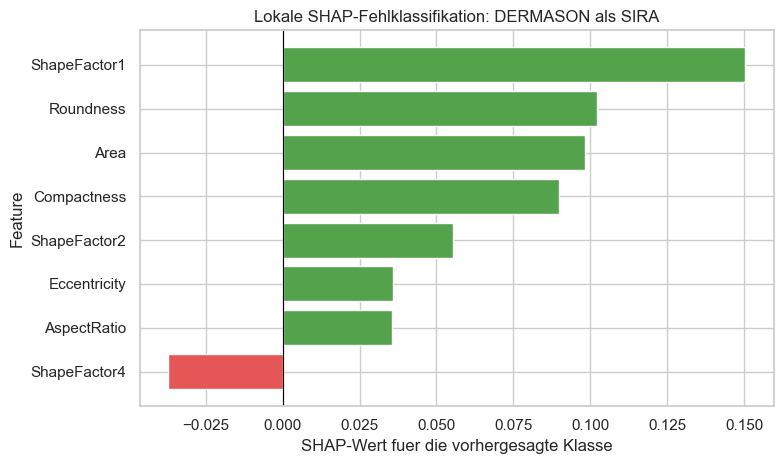

In [12]:
plot_df = misclassified_local_df.sort_values("shap_value")
colors = np.where(plot_df["shap_value"] >= 0, "#54a24b", "#e45756")
plt.figure(figsize=(8, 4.8))
plt.barh(plot_df["feature"], plot_df["shap_value"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    f"Lokale SHAP-Fehlklassifikation: {misclassified_actual_class} als {misclassified_predicted_class}"
)
plt.xlabel("SHAP-Wert fuer die vorhergesagte Klasse")
plt.ylabel("Feature")
plt.tight_layout()
for output_dir in [NOTEBOOK_DIR, REPORT_GRAPHICS_DIR]:
    plt.savefig(output_dir / "SHAP_Local_Misclassified_RandomForest.pdf", bbox_inches="tight")
plt.show()

In [13]:
misclassified_lime_exp = lime_explainer.explain_instance(
    data_row=misclassified_example.iloc[0].to_numpy(),
    predict_fn=model.predict_proba,
    labels=[misclassified_class_index],
    num_features=len(selected_features),
)

misclassified_lime_df = pd.DataFrame(
    misclassified_lime_exp.as_list(label=misclassified_class_index),
    columns=["condition", "lime_weight"],
).assign(abs_weight=lambda data: data["lime_weight"].abs())
misclassified_lime_df

/Users/lukadeda/xai/projektarbeit/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,condition,lime_weight,abs_weight
0,36324.00 < Area <= 44665.00,0.070449,0.070449
1,0.01 < ShapeFactor1 <= 0.01,0.068987,0.068987
2,0.76 < Compactness <= 0.80,0.054123,0.054123
3,0.83 < Roundness <= 0.88,0.037210,0.037210
4,0.00 < ShapeFactor2 <= 0.00,0.028866,0.028866
5,1.55 < AspectRatio <= 1.71,0.018267,0.018267
6,0.76 < Eccentricity <= 0.81,0.015880,0.015880
7,1.00 < ShapeFactor4 <= 1.00,-0.003302,0.003302


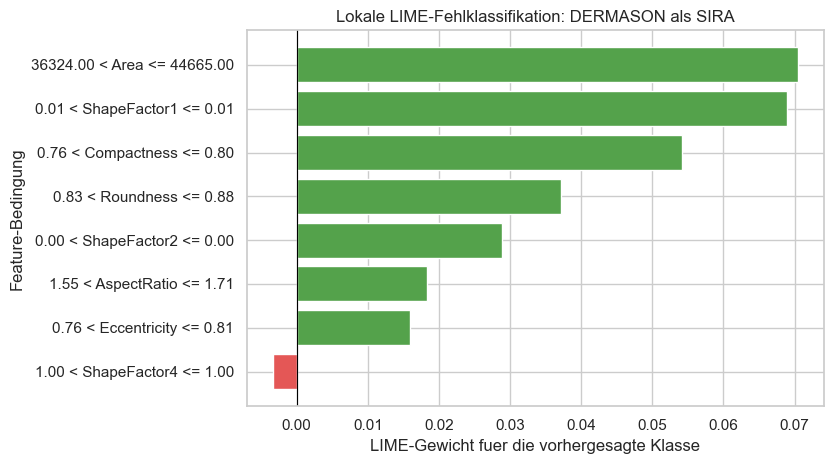

In [14]:
plot_df = misclassified_lime_df.sort_values("lime_weight")
colors = np.where(plot_df["lime_weight"] >= 0, "#54a24b", "#e45756")
plt.figure(figsize=(8.5, 4.8))
plt.barh(plot_df["condition"], plot_df["lime_weight"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    f"Lokale LIME-Fehlklassifikation: {misclassified_actual_class} als {misclassified_predicted_class}"
)
plt.xlabel("LIME-Gewicht fuer die vorhergesagte Klasse")
plt.ylabel("Feature-Bedingung")
plt.tight_layout()
for output_dir in [NOTEBOOK_DIR, REPORT_GRAPHICS_DIR]:
    plt.savefig(output_dir / "LIME_Local_Misclassified_RandomForest.pdf", bbox_inches="tight")
plt.show()